To enhance ORB's capability of evenly distributing the detected features, I'll adopt a Grid approach, segmenting the image in (rows * cols) smaller parts and running them through ORB's feature detector individually.

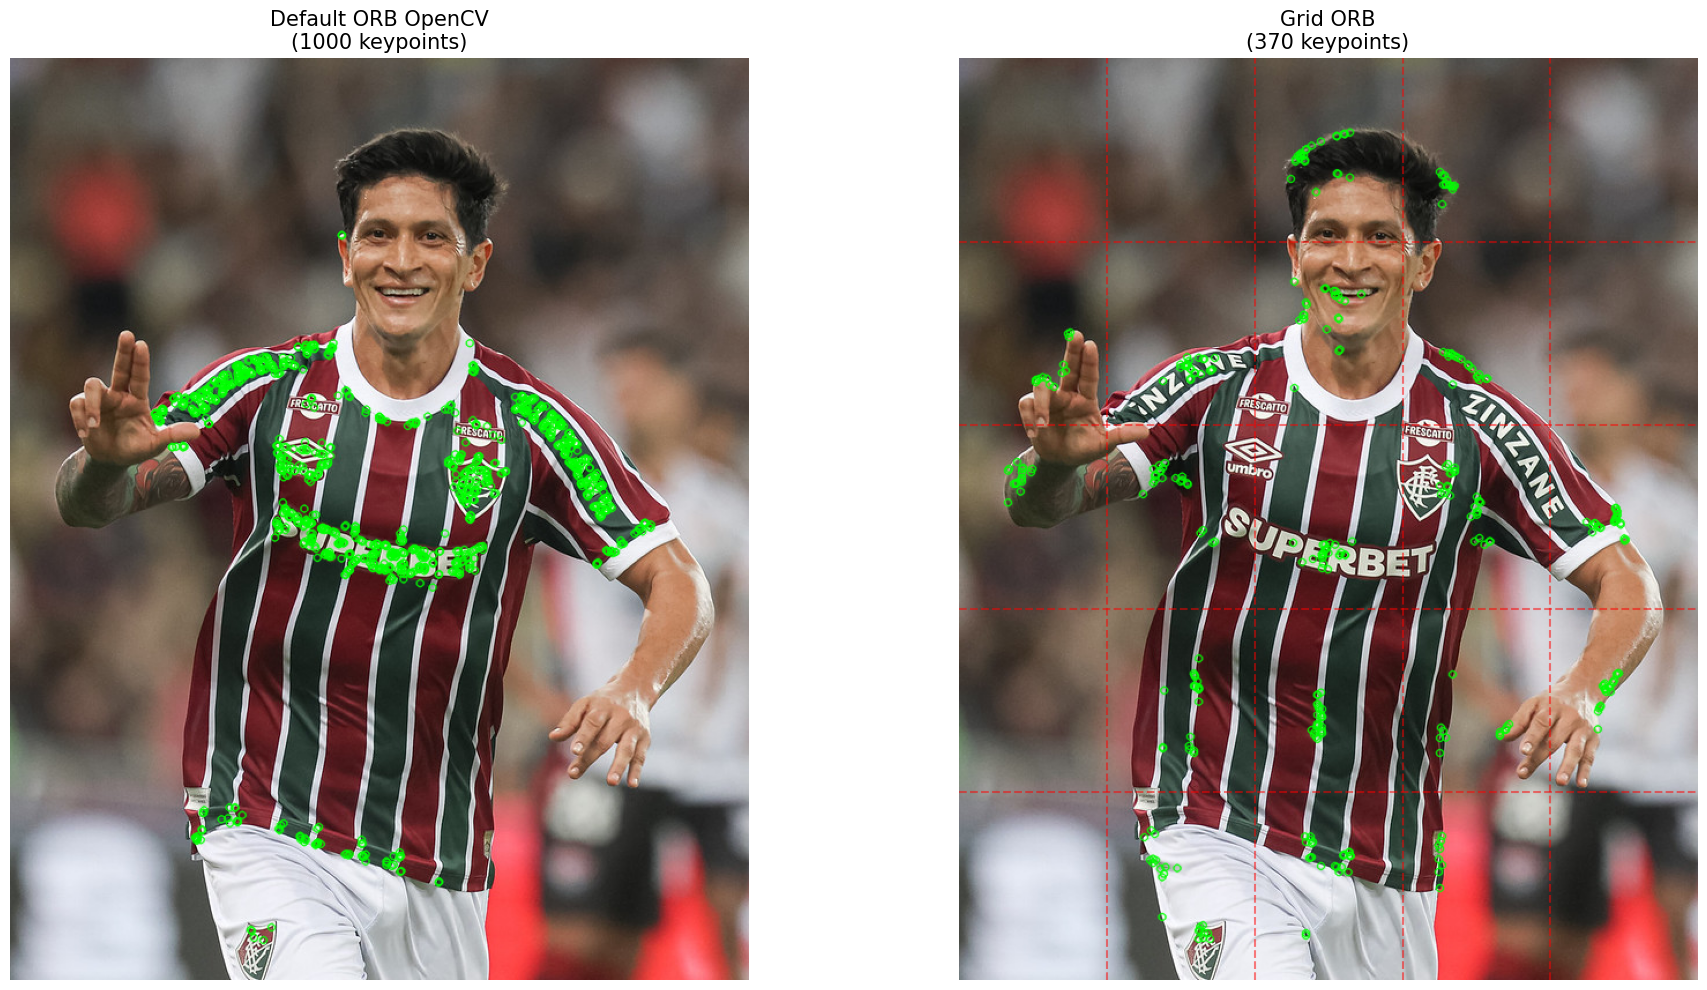

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compare_orb_distributions(img_path, n_features=1000):
    image = cv2.imread(img_path)
    if image is None:
        print("Erro ao carregar a imagem.")
        return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Default opencv ORB
    orb_standard = cv2.ORB_create(nfeatures=n_features)
    kp_std, _ = orb_standard.detectAndCompute(gray, None)

    # GRID ORB
    rows, cols = 5, 5
    features_per_cell = n_features // (rows*cols)   # 40 features per cell
    orb_grid = cv2.ORB_create(nfeatures=features_per_cell)

    h, w = gray.shape
    h_step, w_step = h // rows, w // cols
    kp_grid_total = []

    for r in range(rows):
        for c in range(cols):
            y1, y2 = r * h_step, (r + 1) * h_step
            x1, x2 = c * w_step, (c + 1) * w_step
            roi = gray[y1:y2, x1:x2]
            kp = orb_grid.detect(roi, None)   # keypoints inside the grid
            for k in kp:
                k.pt = (k.pt[0] + x1, k.pt[1] + y1)  # remapping keypoints in the full image
            kp_grid_total.extend(kp)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Frame 1: Default ORB
    img_std = cv2.drawKeypoints(image, kp_std, None, color=(0, 255, 0), flags=0)
    ax1.imshow(cv2.cvtColor(img_std, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Default ORB OpenCV\n({len(kp_std)} keypoints)", fontsize=15)
    ax1.axis('off')

    # Frame 2: Grid ORB
    img_grid = cv2.drawKeypoints(image, kp_grid_total, None, color=(0, 255, 0), flags=0)

    for r in range(1, rows):
        ax2.axhline(y=r * h_step, color='red', linestyle='--', alpha=0.5)
    for c in range(1, cols):
        ax2.axvline(x=c * w_step, color='red', linestyle='--', alpha=0.5)

    ax2.imshow(cv2.cvtColor(img_grid, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Grid ORB\n({len(kp_grid_total)} keypoints)", fontsize=15)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

compare_orb_distributions('germancano.jpg')